# Project 01 (basic) — reference solution: pandas basics with real penguins

**Goal:** practise the basic pandas tools on a real data set: load, inspect,
filter, new columns, group, plot.

**The data:** 344 penguins of three species (Adelie, Chinstrap, Gentoo) from three
islands of the Palmer Archipelago (Antarctica), measured 2007-2009 by
Dr Kristen Gorman — a real research data set and the standard teaching example of
the data science world.

**This is the fully worked solution.** All cells have been executed.

**Reference to the script:** sections 1.3 (descriptive statistics), 1.4 (plots), 1.5 (pandas).

## 1. Loading and first inspection

The first three commands for EVERY new data set: `head()`, `info()`, `describe()`.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


**Read the `info()` output like a professional:**
- 344 rows; `species`, `island`, `sex` are `object` (text/categories), the rest `float64` (metric)
- Some columns have fewer than 344 non-null values → there are **missing values**!

**Task:** count the missing values per column (`isna()` gives True/False, `sum()` counts).

In [3]:
missing = df.isna().sum()
print(missing)

# Mini check — must print True:
print(int(missing.sum()) == 19)

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
True


## 2. Descriptive statistics

`describe()` gives key figures for all metric columns in one go.
For `body_mass_g`, compare the mean and the median (= the 50 % quantile) — if they
lie close together, the distribution is reasonably symmetric (script 1.3).

In [4]:
df.describe().round(1)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.0,342.0,342.0,342.0
mean,43.9,17.2,200.9,4201.8
std,5.5,2.0,14.1,802.0
min,32.1,13.1,172.0,2700.0
25%,39.2,15.6,190.0,3550.0
50%,44.4,17.3,197.0,4050.0
75%,48.5,18.7,213.0,4750.0
max,59.6,21.5,231.0,6300.0


## 3. Selecting and filtering

The two basic patterns:
- column: `df["body_mass_g"]`
- rows via a boolean mask: `df[df["species"] == "Gentoo"]`

**Tasks:**
1. `gentoo`: all Gentoo penguins
2. `heavy`: all penguins over 5000 g
3. `gentoo_biscoe`: all Gentoo from the island of Biscoe (two conditions: `&` and brackets around each condition!)

In [5]:
gentoo = df[df["species"] == "Gentoo"]
heavy = df[df["body_mass_g"] > 5000]
gentoo_biscoe = df[(df["species"] == "Gentoo") & (df["island"] == "Biscoe")]

# Mini checks — all True?
print(len(gentoo) == 124)
print(len(heavy) == 61)
print(len(gentoo_biscoe) == 124)   # Aha: ALL Gentoo live on Biscoe!

True
True
True


## 4. New columns (vectorised!)

No `for` over rows — whole columns at once (script 1.5).

**Tasks:**
1. `mass_kg`: body mass in kilograms
2. `bill_ratio`: `bill_length_mm / bill_depth_mm` (a shape feature)

In [6]:
df["mass_kg"] = df["body_mass_g"] / 1000
df["bill_ratio"] = df["bill_length_mm"] / df["bill_depth_mm"]

# Mini check:
print(round(float(df["mass_kg"].max()), 2) == 6.3)
df[["species", "mass_kg", "bill_ratio"]].head(3)

True


,species,mass_kg,bill_ratio
0,Adelie,3.75,2.090909
1,Adelie,3.80,2.270115
2,Adelie,3.25,2.238889


## 5. Grouping: the workhorse

"Do the species differ?" is a `groupby` question (script 2.3: split-apply-combine).

**Task:** mean body mass (g) per species. After that (given): several key figures at
once with `.agg()`.

In [7]:
mass_per_species = df.groupby("species")["body_mass_g"].mean()
print(mass_per_species.round(0))

# Mini check: Gentoo is by far the heaviest species
print(mass_per_species.idxmax() == "Gentoo")

species
Adelie       3701.0
Chinstrap    3733.0
Gentoo       5076.0
Name: body_mass_g, dtype: float64
True


In [8]:
# Several key figures at once — given:
df.groupby("species")["body_mass_g"].agg(["count", "mean", "median", "std"]).round(1)

,count,mean,median,std
species,,,,
Adelie,151,3700.7,3700.0,458.6
Chinstrap,68,3733.1,3700.0,384.3
Gentoo,123,5076.0,5000.0,504.1


## 6. The basic plots

Now the three most important plot types from script 1.4 — every figure gets one
sentence of interpretation (posed as a question alongside).

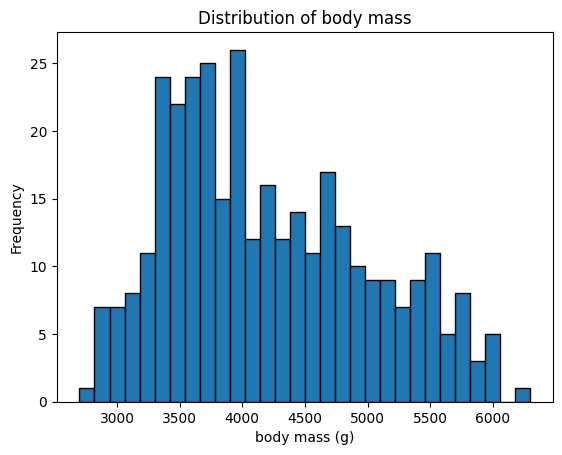

In [9]:
# Histogram: how is the body mass distributed?
df["body_mass_g"].plot.hist(bins=30, edgecolor="black")
plt.xlabel("body mass (g)"); plt.title("Distribution of body mass")
plt.show()
# A question for you: the distribution has two "humps" (bimodal) — which explanation
# does the groupby from step 5 provide?

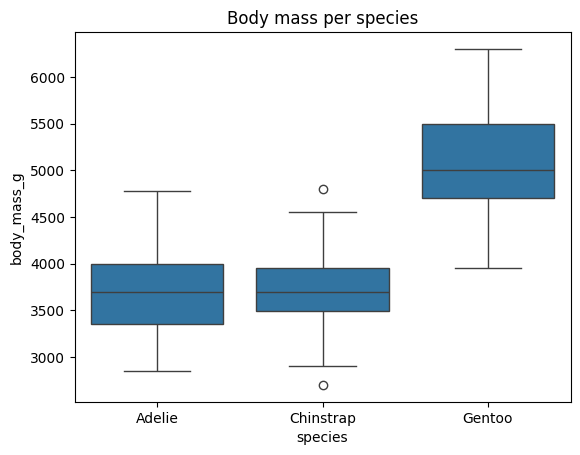

In [10]:
# Box plot per species: COMPARING distributions
sns.boxplot(data=df, x="species", y="body_mass_g")
plt.title("Body mass per species")
plt.show()
# Question: does this picture fit the bimodal distribution above?

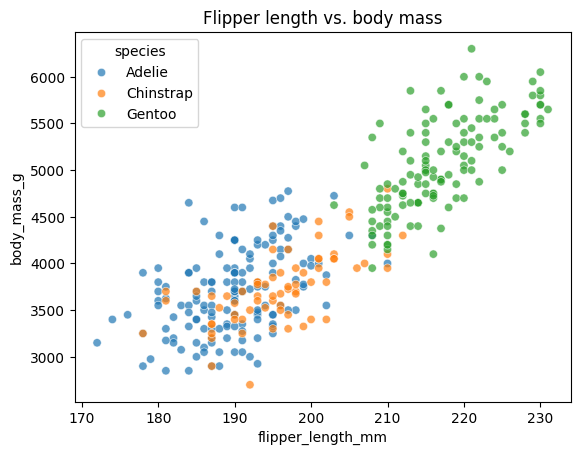

In [11]:
# Scatter plot: relationship between two metric variables, coloured by species
sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g", hue="species", alpha=0.7)
plt.title("Flipper length vs. body mass")
plt.show()
# Question: is the relationship positive? Do the species form separate clouds?

## 7. Correlation

**Task:** compute the Pearson correlation between `flipper_length_mm` and
`body_mass_g` (the `.corr()` method of one Series with another).

In [12]:
r = df["flipper_length_mm"].corr(df["body_mass_g"])
print(f"Pearson r = {r:.3f}")

# Mini check: strongly positive relationship
print(r > 0.85)

Pearson r = 0.871
True


**Interpretation:** $r \approx 0.87$ — bigger flippers, heavier penguins, a clear,
almost linear relationship (the scatter plot confirms the picture — script 2.4:
never interpret $r$ without a plot).

## Done — what you can do now

- first inspection in your sleep: `head` / `info` / `describe` / `isna().sum()`
- filtering with boolean masks, also combined
- vectorised columns, `groupby` aggregation
- histogram, box plot, scatter plot — and a statement about each

**Bonus tasks** (optional):
1. Which island has the most penguins? (`value_counts()`)
2. Are there size differences between males and females *within* a species?
   (`groupby(["species", "sex"])`)
3. Look at `bill_ratio` per species as a box plot — could you recognise the species
   from the bill alone?